In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv("./../data/filtered_diamonds.csv")
df

,Id,Shape,Weight,Clarity,Colour,Cut,Polish,Symmetry,Fluorescence,Price,Length,Width,Depth
0,1638147,CUSHION,0.549805,SI2,E,EX,EX,VG,N,1378.65,5.050781,4.351562,2.939453
1,1630155,CUSHION,0.500000,VVS1,FANCY,EX,EX,VG,F,1379.74,4.601562,4.308594,2.919922
2,1612606,CUSHION,0.509766,VS2,H,EX,EX,VG,N,1380.19,4.710938,4.351562,2.939453
3,1638140,CUSHION,0.500000,VS2,H,EX,EX,VG,N,1380.61,4.910156,4.261719,2.880859
4,1536093,CUSHION,0.529785,SI1,D,EX,VG,VG,N,1383.13,4.699219,4.460938,3.009766
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5890,1751206,ROUND,0.500000,SI1,E,EX,EX,EX,N,2453.10,5.000000,5.039062,3.179688
5891,1773024,ROUND,0.500000,SI1,E,EX,EX,EX,N,2453.10,5.031250,5.058594,3.160156
5892,1789435,ROUND,0.500000,VS2,D,VG,EX,VG,N,2453.20,4.929688,4.960938,3.189453
5893,1774887,ROUND,0.520020,SI1,H,EX,EX,EX,N,2453.41,5.109375,5.128906,3.199219


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5895 entries, 0 to 5894
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            5895 non-null   object 
 1   Shape         5895 non-null   object 
 2   Weight        5895 non-null   float64
 3   Clarity       5895 non-null   object 
 4   Colour        5895 non-null   object 
 5   Cut           5895 non-null   object 
 6   Polish        5895 non-null   object 
 7   Symmetry      5895 non-null   object 
 8   Fluorescence  5895 non-null   object 
 9   Price         5895 non-null   float64
 10  Length        5895 non-null   float64
 11  Width         5895 non-null   float64
 12  Depth         5895 non-null   float64
dtypes: float64(5), object(8)
memory usage: 598.8+ KB


In [4]:
df.drop(['Id'], axis = 1, inplace = True) 

In [5]:
def ordinal_converter(data, order):
    nums = list(range(len(order)))
    map = dict(zip(order, nums))
    return data.replace(map)

In [6]:
df.Fluorescence = ordinal_converter(df.Fluorescence, ['N', 'M', 'F', 'SL', 'ST', 'VS', 'VSL'])

In [7]:
df.Symmetry = ordinal_converter(df.Symmetry, ['FR', 'GD', 'VG', 'EX'])

In [8]:
df.Polish = ordinal_converter(df.Polish, ['F', 'GD', 'VG', 'EX'])

In [9]:
df.Cut = ordinal_converter(df.Cut, ['F', 'GD', 'VG', 'EX'])

In [10]:
df.Colour = ordinal_converter(
    df.Colour,
    [
        "Y-Z",
        "W-X",
        "W",
        "U-V",
        "S-T",
        "Q-R",
        "O-P",
        "O",
        "N",
        "M",
        "L",
        "K",
        "J",
        "I",
        "H",
        "G",
        "F",
        "E",
        "D",
        "FANCY",
    ],
)

In [11]:
['IF', 'VVS1', 'VVS2', 'VS1','VS2','SI1','SI2','I1','I2', 'I3'][::-1]

['I3', 'I2', 'I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

In [12]:
df.Clarity = ordinal_converter(df.Clarity,['I3', 'I2', 'I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'])

In [13]:
df

,Shape,Weight,Clarity,Colour,Cut,Polish,Symmetry,Fluorescence,Price,Length,Width,Depth
0,CUSHION,0.549805,3,17,3,3,2,0,1378.65,5.050781,4.351562,2.939453
1,CUSHION,0.500000,8,19,3,3,2,2,1379.74,4.601562,4.308594,2.919922
2,CUSHION,0.509766,5,14,3,3,2,0,1380.19,4.710938,4.351562,2.939453
3,CUSHION,0.500000,5,14,3,3,2,0,1380.61,4.910156,4.261719,2.880859
4,CUSHION,0.529785,4,18,3,2,2,0,1383.13,4.699219,4.460938,3.009766
...,...,...,...,...,...,...,...,...,...,...,...,...
5890,ROUND,0.500000,4,17,3,3,3,0,2453.10,5.000000,5.039062,3.179688
5891,ROUND,0.500000,4,17,3,3,3,0,2453.10,5.031250,5.058594,3.160156
5892,ROUND,0.500000,5,18,2,3,2,0,2453.20,4.929688,4.960938,3.189453
5893,ROUND,0.520020,4,14,3,3,3,0,2453.41,5.109375,5.128906,3.199219


In [14]:
model_OHE = ColumnTransformer(
    [('Shape_encoder', OneHotEncoder(),['Shape'])],
    remainder = 'passthrough'
    )
transform = model_OHE.fit_transform(df)
transform

array([[1.       , 0.       , 0.       , ..., 5.0507812, 4.3515625,
        2.9394531],
       [1.       , 0.       , 0.       , ..., 4.6015625, 4.3085938,
        2.9199219],
       [1.       , 0.       , 0.       , ..., 4.7109375, 4.3515625,
        2.9394531],
       ...,
       [0.       , 0.       , 0.       , ..., 4.9296875, 4.9609375,
        3.1894531],
       [0.       , 0.       , 0.       , ..., 5.109375 , 5.1289062,
        3.1992188],
       [0.       , 0.       , 0.       , ..., 5.0898438, 5.1289062,
        3.1191406]])

In [15]:
# transform_df = pd.DataFrame(transform)
transform_df = pd.DataFrame(transform, columns=['Shape_CUSHION', 'Shape_EMERALD', 'Shape_HEART', 'Shape_MARQUISE', 'Shape_OVAL', 'Shape_PEAR', 'Shape_PRINCESS', 'Shape_ROUND','Weight', 'Clarity', 'Colour', 'Cut', 'Polish', 'Symmetry', 'Fluorescence', 'Price', 'Length','Width', 'Depth'])
transform_df

,Shape_CUSHION,Shape_EMERALD,Shape_HEART,Shape_MARQUISE,Shape_OVAL,Shape_PEAR,Shape_PRINCESS,Shape_ROUND,Weight,Clarity,Colour,Cut,Polish,Symmetry,Fluorescence,Price,Length,Width,Depth
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.549805,3.0,17.0,3.0,3.0,2.0,0.0,1378.65,5.050781,4.351562,2.939453
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500000,8.0,19.0,3.0,3.0,2.0,2.0,1379.74,4.601562,4.308594,2.919922
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.509766,5.0,14.0,3.0,3.0,2.0,0.0,1380.19,4.710938,4.351562,2.939453
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500000,5.0,14.0,3.0,3.0,2.0,0.0,1380.61,4.910156,4.261719,2.880859
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.529785,4.0,18.0,3.0,2.0,2.0,0.0,1383.13,4.699219,4.460938,3.009766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5890,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.500000,4.0,17.0,3.0,3.0,3.0,0.0,2453.10,5.000000,5.039062,3.179688
5891,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.500000,4.0,17.0,3.0,3.0,3.0,0.0,2453.10,5.031250,5.058594,3.160156
5892,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.500000,5.0,18.0,2.0,3.0,2.0,0.0,2453.20,4.929688,4.960938,3.189453
5893,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.520020,4.0,14.0,3.0,3.0,3.0,0.0,2453.41,5.109375,5.128906,3.199219


In [17]:
transform_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5895 entries, 0 to 5894
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Shape_CUSHION   5895 non-null   float64
 1   Shape_EMERALD   5895 non-null   float64
 2   Shape_HEART     5895 non-null   float64
 3   Shape_MARQUISE  5895 non-null   float64
 4   Shape_OVAL      5895 non-null   float64
 5   Shape_PEAR      5895 non-null   float64
 6   Shape_PRINCESS  5895 non-null   float64
 7   Shape_ROUND     5895 non-null   float64
 8   Weight          5895 non-null   float64
 9   Clarity         5895 non-null   float64
 10  Colour          5895 non-null   float64
 11  Cut             5895 non-null   float64
 12  Polish          5895 non-null   float64
 13  Symmetry        5895 non-null   float64
 14  Fluorescence    5895 non-null   float64
 15  Price           5895 non-null   float64
 16  Length          5895 non-null   float64
 17  Width           5895 non-null   f

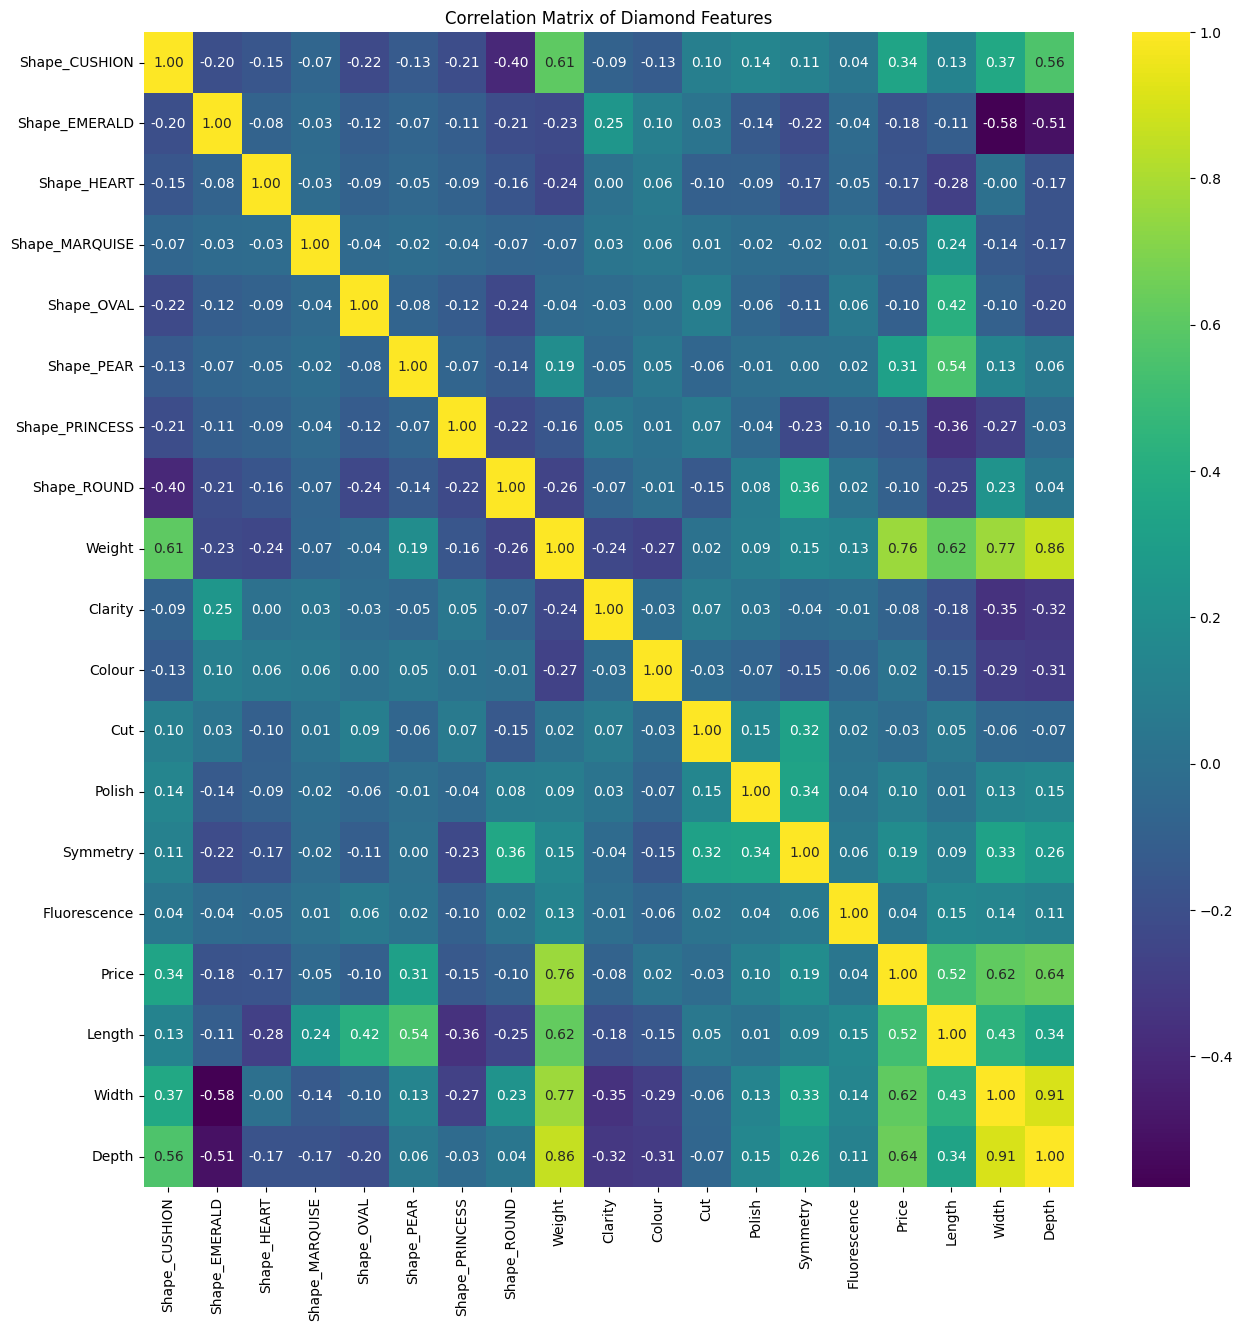

In [20]:
plt.figure(figsize=(15,15))
sns.heatmap(transform_df.corr(numeric_only = True), annot=True, fmt=".2f", cmap="viridis")
plt.title('Correlation Matrix of Diamond Features')
plt.show()

In [21]:
transform_df.to_csv("./../data/transform_diamonds.csv", index=False)

In [ ]:
transform_df.to_parquet("./../data/transform_diamonds.br", compression="BROTLI")